# Сравнительный анализ Single-GPU и Multi-GPU для MGPU-VoxelWaterfall

Объединяет два 100-секундных тестовых прогона одной сцены:

- `SingleGpuFull`;
- `MultiGpuFull` с передачей `CopyOnlyCrossAdapter`.

Основная метрика производительности — `present_to_present_ms`. Для удобства также приводится throughput FPS, рассчитанный как `1000 / среднее время кадра`.

Первые 5 секунд каждого прогона исключаются только из steady-state анализа. Полные значения из файлов summary сохраняются отдельно.

In [17]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install ipython


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from pathlib import Path
import json
import math
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 220)

STEADY_START_SECONDS = 5.0
MODE_ORDER = ["Single GPU", "Multi GPU"]
FRAME_TIME = "present_to_present_ms"

NOTEBOOK_DIR = Path.cwd().resolve()

ROOT = NOTEBOOK_DIR.parent
DATA_DIR = ROOT / "artifacts"
OUTPUT_DIR = ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8-sig"))


RUN_PATHS = {
    "Single GPU": DATA_DIR / "paper_quick_single_001",
    "Multi GPU": DATA_DIR / "paper_quick_mgpu_001",
}

environments = {
    label: load_json(path / "environment.json")
    for label, path in RUN_PATHS.items()
}

summaries = {
    label: load_json(path / "quick_metrics_summary.json")
    for label, path in RUN_PATHS.items()
}

frames_by_mode = {}
for label, path in RUN_PATHS.items():
    frame = pd.read_csv(path / "quick_metrics.csv", low_memory=False)
    frame["run_label"] = label
    frame["simulation_step_delta"] = frame["simulation_frame_index"].diff().fillna(frame["simulation_frame_index"].iloc[0])
    frame["simulation_advanced"] = frame["simulation_step_delta"] > 0
    frame["rendered_voxels"] = frame["primary_rendered_voxels"] + frame["secondary_rendered_voxels"]
    frame["second_bin"] = np.floor(frame["elapsed_seconds"]).astype(int)
    frame["frame_phase_30"] = frame["frame_index"] % 30
    frame["transfer_mib"] = frame["total_cross_adapter_bytes"] / 2**20
    frame["cpu_non_wait_ms"] = frame[FRAME_TIME] - frame["cpu_wait_ms"]
    frames_by_mode[label] = frame

frames = pd.concat(frames_by_mode.values(), ignore_index=True)
steady_by_mode = {
    label: frame.loc[frame["elapsed_seconds"] >= STEADY_START_SECONDS].copy()
    for label, frame in frames_by_mode.items()
}
steady_frames = pd.concat(steady_by_mode.values(), ignore_index=True)


def save_show(filename: str):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


print(f"Каталог анализа: {ROOT}")
print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}; NumPy: {np.__version__}")

Каталог анализа: F:\projects\Multi-GPU-Render-DX12
Python: 3.14.0
pandas: 3.0.3; NumPy: 2.5.0


## 1.Конфигурация системы

Ниже аппаратная конфигурация переведена из JSON в обычные таблицы. Primary GPU формирует финальный кадр и владеет swapchain. Secondary GPU участвует только в `MultiGpuFull`.

In [19]:
def parse_video_controllers(environment: dict) -> list[dict]:
    try:
        value = json.loads(environment.get("windows_video_controllers_json", "[]"))
        return value if isinstance(value, list) else []
    except json.JSONDecodeError:
        return []


def driver_for_adapter(environment: dict, adapter_name: str) -> str:
    for controller in parse_video_controllers(environment):
        if controller.get("Name") == adapter_name:
            return str(controller.get("DriverVersion", "не указан"))
    return "не найден"

single_env = environments["Single GPU"]
multi_env = environments["Multi GPU"]

hardware_table = pd.DataFrame([
    {"Компонент": "Процессор", "Значение": single_env["cpu_model"]},
    {"Компонент": "Логических процессоров", "Значение": single_env["logical_processor_count"]},
    {"Компонент": "Оперативная память", "Значение": f"{single_env['ram_bytes'] / 2**30:.2f} GiB"},
    {"Компонент": "Операционная система", "Значение": single_env["operating_system"]},
    {"Компонент": "Primary GPU", "Значение": single_env["primary_gpu"]["name"]},
    {"Компонент": "Память primary GPU", "Значение": f"{single_env['primary_gpu']['dedicated_video_memory_bytes'] / 2**30:.2f} GiB"},
    {"Компонент": "Драйвер primary GPU", "Значение": driver_for_adapter(single_env, single_env["primary_gpu"]["name"])},
    {"Компонент": "Secondary GPU", "Значение": single_env["secondary_gpu"]["name"]},
    {"Компонент": "Выделенная память secondary GPU", "Значение": f"{single_env['secondary_gpu']['dedicated_video_memory_bytes'] / 2**20:.1f} MiB"},
    {"Компонент": "Драйвер secondary GPU", "Значение": driver_for_adapter(single_env, single_env["secondary_gpu"]["name"])},
])

display(hardware_table)

experiment_table = pd.DataFrame([
    {
        "Параметр": "Режим",
        "Single GPU": single_env["actual_mode"],
        "Multi GPU": multi_env["actual_mode"],
    },
    {
        "Параметр": "Профиль сцены",
        "Single GPU": single_env["profile"],
        "Multi GPU": multi_env["profile"],
    },
    {
        "Параметр": "Preset сцены",
        "Single GPU": single_env["scene_preset"],
        "Multi GPU": multi_env["scene_preset"],
    },
    {
        "Параметр": "Seed",
        "Single GPU": single_env["seed"],
        "Multi GPU": multi_env["seed"],
    },
    {
        "Параметр": "Всего вокселей",
        "Single GPU": single_env["total_voxels"],
        "Multi GPU": multi_env["total_voxels"],
    },
    {
        "Параметр": "Статические / динамические",
        "Single GPU": f"{single_env['static_voxels']} / {single_env['dynamic_particles']}",
        "Multi GPU": f"{multi_env['static_voxels']} / {multi_env['dynamic_particles']}",
    },
    {
        "Параметр": "Render resolution",
        "Single GPU": f"{single_env['render_width']} × {single_env['render_height']}",
        "Multi GPU": f"{multi_env['render_width']} × {multi_env['render_height']}",
    },
    {
        "Параметр": "Temporal policy / interval",
        "Single GPU": f"{single_env['temporal_policy']} / {single_env['temporal_interval']}",
        "Multi GPU": f"{multi_env['temporal_policy']} / {multi_env['temporal_interval']}",
    },
    {
        "Параметр": "Spatial LOD",
        "Single GPU": single_env["spatial_lod_policy"],
        "Multi GPU": multi_env["spatial_lod_policy"],
    },
    {
        "Параметр": "Transfer mode",
        "Single GPU": "не используется",
        "Multi GPU": multi_env["transfer_mode"],
    },
    {
        "Параметр": "Запрошенная доля secondary",
        "Single GPU": "0%",
        "Multi GPU": f"{100 * multi_env['secondary_share']:.1f}%",
    },
])

display(experiment_table)

provenance_table = pd.DataFrame([
    {
        "Режим": label,
        "Build": env["build_configuration"],
        "Git commit": env["git_commit"],
        "Git state": env["git_dirty_state"],
        "Длительность, с": env["duration_seconds_actual"],
        "Кадров": env["measured_frames"],
    }
    for label, env in environments.items()
])

display(provenance_table)

hardware_table.to_csv(OUTPUT_DIR / "system_hardware.csv", index=False, encoding="utf-8-sig")
experiment_table.to_csv(OUTPUT_DIR / "experiment_configuration.csv", index=False, encoding="utf-8-sig")
provenance_table.to_csv(OUTPUT_DIR / "run_provenance.csv", index=False, encoding="utf-8-sig")

,Компонент,Значение
0,Процессор,AMD Ryzen 9 9950X3D 16-Core Processor
1,Логических процессоров,32
2,Оперативная память,31.11 GiB
3,Операционная система,Windows
4,Primary GPU,NVIDIA GeForce RTX 5080
5,Память primary GPU,15.60 GiB
6,Драйвер primary GPU,32.0.15.9621
7,Secondary GPU,AMD Radeon(TM) Graphics
8,Выделенная память secondary GPU,465.8 MiB
9,Драйвер secondary GPU,32.0.13018.6


,Параметр,Single GPU,Multi GPU
0,Режим,SingleGpuFull,MultiGpuFull
1,Профиль сцены,MixedStaticAndDynamic,MixedStaticAndDynamic
2,Preset сцены,MixedVoxelEnvironment,MixedVoxelEnvironment
3,Seed,1337,1337
4,Всего вокселей,710566,710566
5,Статические / динамические,98556 / 612010,98556 / 612010
6,Render resolution,1920 × 1080,1920 × 1080
7,Temporal policy / interval,Full / 1,Full / 1
8,Spatial LOD,Off,Off
9,Transfer mode,не используется,CopyOnlyCrossAdapter


,Режим,Build,Git commit,Git state,"Длительность, с",Кадров
0,Single GPU,Release,414c2617585fd9d244c1e8baff228fa8576d4b07,dirty,100.001,6954
1,Multi GPU,Release,414c2617585fd9d244c1e8baff228fa8576d4b07,dirty,100.013,2877


## 2. Контроль качества и сопоставимости данных

In [20]:
def bool_status(value: bool, warn: bool = False) -> str:
    if value:
        return "PASS"
    return "WARN" if warn else "FAIL"

quality_rows = []
for label in MODE_ORDER:
    frame = frames_by_mode[label]
    env = environments[label]
    summary = summaries[label]
    rendered_total = frame["rendered_voxels"]
    full_workload = frame.loc[rendered_total == frame["total_voxels"]]
    first_full = float(full_workload["elapsed_seconds"].min()) if not full_workload.empty else np.nan

    calculated_mean_ms = float(frame[FRAME_TIME].mean())
    calculated_throughput_fps = 1000.0 / calculated_mean_ms

    quality_rows.append({
        "Режим": label,
        "Строк": len(frame),
        "Пропусков": int(frame.isna().sum().sum()),
        "Полных дубликатов": int(frame.duplicated().sum()),
        "frame_index последовательный": bool(np.array_equal(frame["frame_index"].to_numpy(), np.arange(frame["frame_index"].iloc[0], frame["frame_index"].iloc[0] + len(frame)))),
        "elapsed_seconds монотонный": bool(frame["elapsed_seconds"].is_monotonic_increasing),
        "requested == actual": bool((frame["requested_mode"] == frame["actual_mode"]).all()),
        "frame_time == present_to_present": bool(np.allclose(frame["frame_time_ms"], frame[FRAME_TIME])),
        "Первый полный workload, с": first_full,
        "Среднее ms из CSV": calculated_mean_ms,
        "Среднее ms из summary": float(summary["average_frame_time_ms"]),
        "Throughput FPS из CSV": calculated_throughput_fps,
        "FPS из summary": float(summary["average_fps"]),
    })

quality_table = pd.DataFrame(quality_rows)
display(quality_table.round(5))

comparability_checks = [
    ("Одинаковый CPU", single_env["cpu_model"] == multi_env["cpu_model"], True),
    ("Одинаковый primary GPU", single_env["primary_gpu"]["name"] == multi_env["primary_gpu"]["name"], True),
    ("Одинаковый secondary GPU", single_env["secondary_gpu"]["name"] == multi_env["secondary_gpu"]["name"], True),
    ("Одинаковая сцена и profile", (single_env["scene_preset"], single_env["profile"]) == (multi_env["scene_preset"], multi_env["profile"]), True),
    ("Одинаковый seed", single_env["seed"] == multi_env["seed"], True),
    ("Одинаковое число вокселей", single_env["total_voxels"] == multi_env["total_voxels"], True),
    ("Одинаковое разрешение", (single_env["render_width"], single_env["render_height"]) == (multi_env["render_width"], multi_env["render_height"]), True),
    ("Одинаковые temporal policy и interval", (single_env["temporal_policy"], single_env["temporal_interval"]) == (multi_env["temporal_policy"], multi_env["temporal_interval"]), True),
    ("Одинаковая LOD policy", single_env["spatial_lod_policy"] == multi_env["spatial_lod_policy"], True),
    ("Одинаковая Release-сборка", single_env["build_configuration"] == multi_env["build_configuration"] == "Release", True),
    ("Одинаковый Git commit", single_env["git_commit"] == multi_env["git_commit"], False),
    ("Оба репозитория clean", single_env["git_dirty_state"] == multi_env["git_dirty_state"] == "clean", False),
    ("Requested mode совпал с actual mode", all((frames_by_mode[label]["requested_mode"] == frames_by_mode[label]["actual_mode"]).all() for label in MODE_ORDER), True),
]

comparability_table = pd.DataFrame([
    {
        "Проверка": name,
        "Результат": bool_status(value, warn=not critical),
        "Критично для строгого сравнения": "да" if critical else "да",
        "Комментарий": "" if value else ("Параметр различается" if "commit" in name else "Условие не выполнено"),
    }
    for name, value, critical in comparability_checks
])

display(comparability_table)

SCIENTIFIC_PAIR_READY = (
    single_env["git_commit"] == multi_env["git_commit"]
    and single_env["git_dirty_state"] == multi_env["git_dirty_state"] == "clean"
)

quality_table.to_csv(OUTPUT_DIR / "data_quality.csv", index=False, encoding="utf-8-sig")
comparability_table.to_csv(OUTPUT_DIR / "comparability_audit.csv", index=False, encoding="utf-8-sig")

if SCIENTIFIC_PAIR_READY:
    display(Markdown("**Статус сопоставимости: PASS.**"))
else:
    display(Markdown("**Статус сопоставимости: DIAGNOSTIC ONLY.** Версии исходного кода не образуют clean matched pair."))

,Режим,Строк,Пропусков,Полных дубликатов,frame_index последовательный,elapsed_seconds монотонный,requested == actual,frame_time == present_to_present,"Первый полный workload, с",Среднее ms из CSV,Среднее ms из summary,Throughput FPS из CSV,FPS из summary
0,Single GPU,6954,0,0,True,True,True,True,0.17240,14.37614,14.3761,69.55972,69.5597
1,Multi GPU,2877,0,0,True,True,True,True,0.20055,34.75203,34.7520,28.77530,28.7753


,Проверка,Результат,Критично для строгого сравнения,Комментарий
0,Одинаковый CPU,PASS,да,
1,Одинаковый primary GPU,PASS,да,
2,Одинаковый secondary GPU,PASS,да,
3,Одинаковая сцена и profile,PASS,да,
4,Одинаковый seed,PASS,да,
5,Одинаковое число вокселей,PASS,да,
6,Одинаковое разрешение,PASS,да,
7,Одинаковые temporal policy и interval,PASS,да,
8,Одинаковая LOD policy,PASS,да,
9,Одинаковая Release-сборка,PASS,да,


**Статус сопоставимости: DIAGNOSTIC ONLY.** Версии исходного кода не образуют clean matched pair.

## 3. Основные показатели производительности

Показатели ниже приводятся для полного прогона и steady-state участка после 5 секунд.

In [21]:
def slow_tail_fps(series: pd.Series, fraction: float) -> float:
    count = max(1, math.ceil(len(series) * fraction))
    return 1000.0 / series.nlargest(count).mean()


def metric_row(label: str, frame: pd.DataFrame, window: str) -> dict:
    values = frame[FRAME_TIME].dropna()
    mean_ms = values.mean()
    return {
        "Режим": label,
        "Окно": window,
        "Кадров": len(values),
        "Среднее, ms": mean_ms,
        "Медиана, ms": values.median(),
        "P95, ms": values.quantile(0.95),
        "P99, ms": values.quantile(0.99),
        "P99.9, ms": values.quantile(0.999),
        "Максимум, ms": values.max(),
        "Std, ms": values.std(),
        "CV": values.std() / mean_ms,
        "Throughput FPS": 1000.0 / mean_ms,
        "FPS по P99": 1000.0 / values.quantile(0.99),
        "FPS худшего 1%": slow_tail_fps(values, 0.01),
        "FPS худшего 0.1%": slow_tail_fps(values, 0.001),
    }

summary_rows = []
for label in MODE_ORDER:
    summary_rows.append(metric_row(label, frames_by_mode[label], "Полный прогон"))
    summary_rows.append(metric_row(label, steady_by_mode[label], "Steady-state ≥ 5 с"))

performance_summary = pd.DataFrame(summary_rows)
display(performance_summary.round(3))

steady_summary = performance_summary[performance_summary["Окно"] == "Steady-state ≥ 5 с"].set_index("Режим")
single_metrics = steady_summary.loc["Single GPU"]
multi_metrics = steady_summary.loc["Multi GPU"]

relative_table = pd.DataFrame([
    {
        "Показатель": "Throughput FPS",
        "Single GPU": single_metrics["Throughput FPS"],
        "Multi GPU": multi_metrics["Throughput FPS"],
        "Отношение Multi / Single": multi_metrics["Throughput FPS"] / single_metrics["Throughput FPS"],
        "Изменение Multi относительно Single, %": 100.0 * (multi_metrics["Throughput FPS"] / single_metrics["Throughput FPS"] - 1.0),
    },
    {
        "Показатель": "Среднее время кадра, ms",
        "Single GPU": single_metrics["Среднее, ms"],
        "Multi GPU": multi_metrics["Среднее, ms"],
        "Отношение Multi / Single": multi_metrics["Среднее, ms"] / single_metrics["Среднее, ms"],
        "Изменение Multi относительно Single, %": 100.0 * (multi_metrics["Среднее, ms"] / single_metrics["Среднее, ms"] - 1.0),
    },
    {
        "Показатель": "Медиана времени кадра, ms",
        "Single GPU": single_metrics["Медиана, ms"],
        "Multi GPU": multi_metrics["Медиана, ms"],
        "Отношение Multi / Single": multi_metrics["Медиана, ms"] / single_metrics["Медиана, ms"],
        "Изменение Multi относительно Single, %": 100.0 * (multi_metrics["Медиана, ms"] / single_metrics["Медиана, ms"] - 1.0),
    },
    {
        "Показатель": "P95 времени кадра, ms",
        "Single GPU": single_metrics["P95, ms"],
        "Multi GPU": multi_metrics["P95, ms"],
        "Отношение Multi / Single": multi_metrics["P95, ms"] / single_metrics["P95, ms"],
        "Изменение Multi относительно Single, %": 100.0 * (multi_metrics["P95, ms"] / single_metrics["P95, ms"] - 1.0),
    },
    {
        "Показатель": "P99 времени кадра, ms",
        "Single GPU": single_metrics["P99, ms"],
        "Multi GPU": multi_metrics["P99, ms"],
        "Отношение Multi / Single": multi_metrics["P99, ms"] / single_metrics["P99, ms"],
        "Изменение Multi относительно Single, %": 100.0 * (multi_metrics["P99, ms"] / single_metrics["P99, ms"] - 1.0),
    },
    {
        "Показатель": "FPS худшего 1%",
        "Single GPU": single_metrics["FPS худшего 1%"],
        "Multi GPU": multi_metrics["FPS худшего 1%"],
        "Отношение Multi / Single": multi_metrics["FPS худшего 1%"] / single_metrics["FPS худшего 1%"],
        "Изменение Multi относительно Single, %": 100.0 * (multi_metrics["FPS худшего 1%"] / single_metrics["FPS худшего 1%"] - 1.0),
    },
])

display(relative_table.round(3))

performance_summary.to_csv(OUTPUT_DIR / "performance_summary.csv", index=False, encoding="utf-8-sig")
relative_table.to_csv(OUTPUT_DIR / "relative_performance.csv", index=False, encoding="utf-8-sig")

,Режим,Окно,Кадров,"Среднее, ms","Медиана, ms","P95, ms","P99, ms","P99.9, ms","Максимум, ms","Std, ms",CV,Throughput FPS,FPS по P99,FPS худшего 1%,FPS худшего 0.1%
0,Single GPU,Полный прогон,6954,14.376,13.714,18.336,22.477,26.176,57.827,2.128,0.148,69.560,44.490,40.042,29.220
1,Single GPU,Steady-state ≥ 5 с,6676,14.230,13.615,17.487,22.244,25.835,30.340,1.926,0.135,70.272,44.956,41.913,36.738
2,Multi GPU,Полный прогон,2877,34.752,34.639,38.885,54.670,58.584,74.601,5.340,0.154,28.775,18.292,17.611,15.573
3,Multi GPU,Steady-state ≥ 5 с,2727,34.843,34.704,38.776,54.535,57.604,59.392,5.229,0.150,28.701,18.337,17.867,16.986


,Показатель,Single GPU,Multi GPU,Отношение Multi / Single,"Изменение Multi относительно Single, %"
0,Throughput FPS,70.272,28.701,0.408,-59.158
1,"Среднее время кадра, ms",14.230,34.843,2.448,144.846
2,"Медиана времени кадра, ms",13.615,34.704,2.549,154.891
3,"P95 времени кадра, ms",17.487,38.776,2.217,121.740
4,"P99 времени кадра, ms",22.244,54.535,2.452,145.167
5,FPS худшего 1%,41.913,17.867,0.426,-57.370


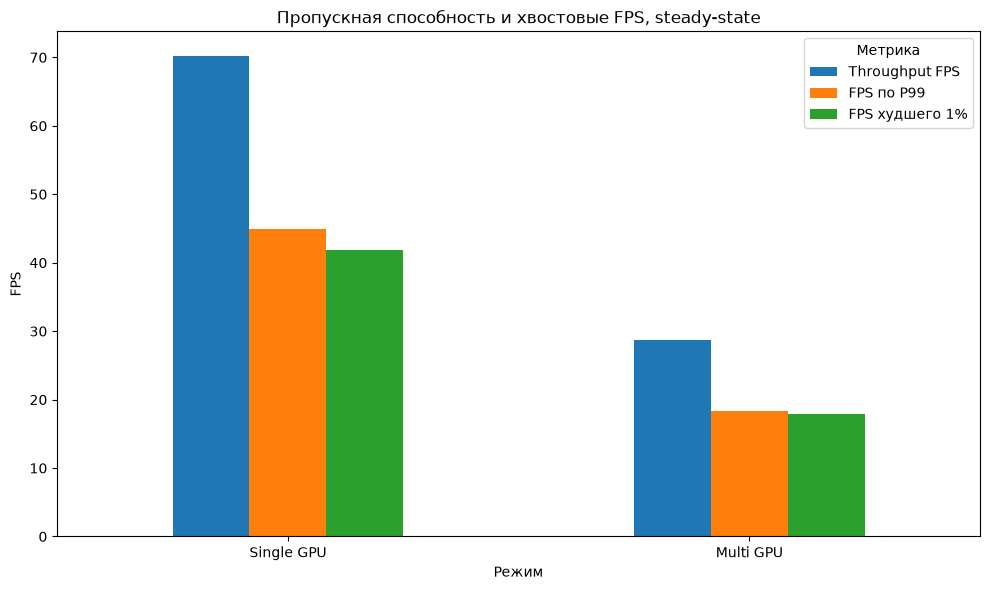

In [22]:
fps_plot = steady_summary[["Throughput FPS", "FPS по P99", "FPS худшего 1%"]]
ax = fps_plot.plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("FPS")
ax.set_xlabel("Режим")
ax.set_title("Пропускная способность и хвостовые FPS, steady-state")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Метрика")
save_show("01_fps_comparison.png")

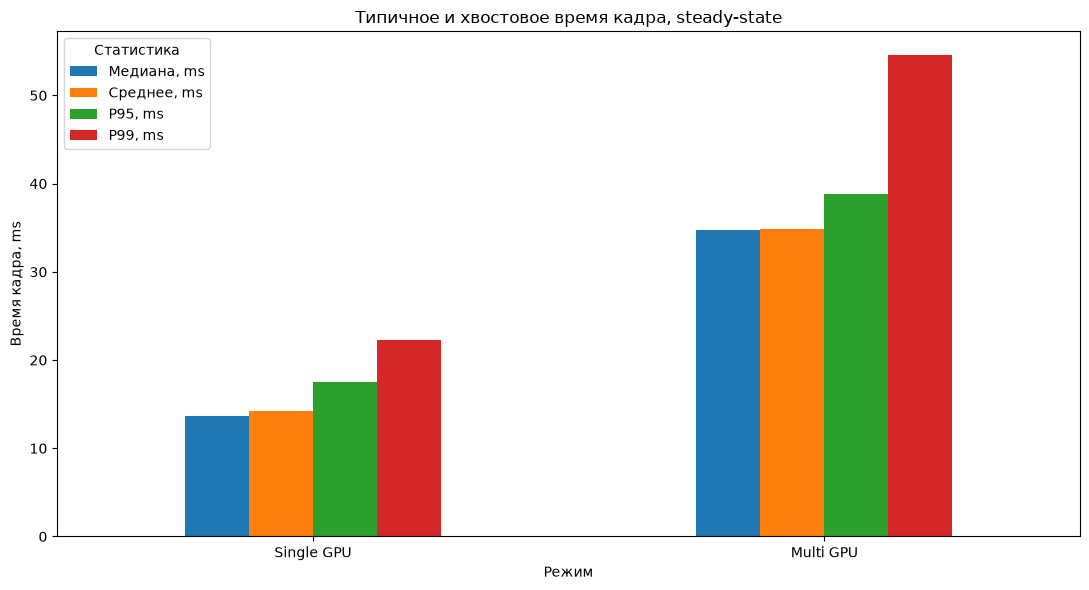

In [23]:
quantile_plot = steady_summary[["Медиана, ms", "Среднее, ms", "P95, ms", "P99, ms"]]
ax = quantile_plot.plot(kind="bar", figsize=(11, 6))
ax.set_ylabel("Время кадра, ms")
ax.set_xlabel("Режим")
ax.set_title("Типичное и хвостовое время кадра, steady-state")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Статистика")
save_show("02_frame_time_quantiles.png")

## 4. Форма распределения и хвост задержек

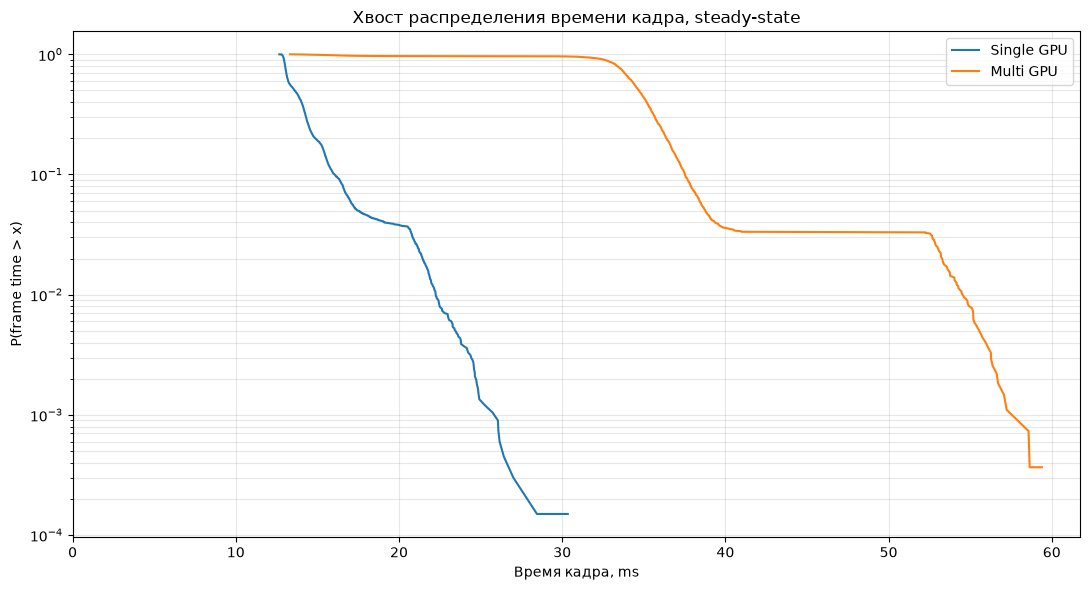

In [24]:
plt.figure(figsize=(11, 6))
for label in MODE_ORDER:
    values = np.sort(steady_by_mode[label][FRAME_TIME].dropna().to_numpy())
    tail_probability = 1.0 - np.arange(1, len(values) + 1) / len(values)
    tail_probability = np.maximum(tail_probability, 1.0 / len(values))
    plt.semilogy(values, tail_probability, label=label)

plt.xlabel("Время кадра, ms")
plt.ylabel("P(frame time > x)")
plt.title("Хвост распределения времени кадра, steady-state")
plt.xlim(left=0)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
save_show("03_frame_time_tail_ccdf.png")

## 5. Стабильность во времени

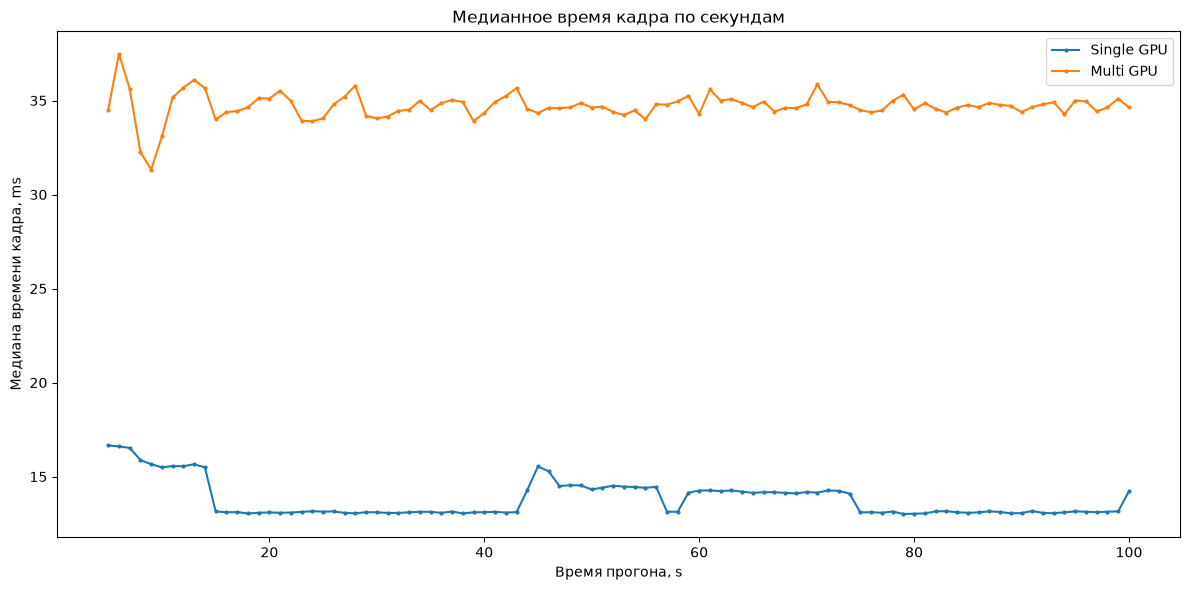

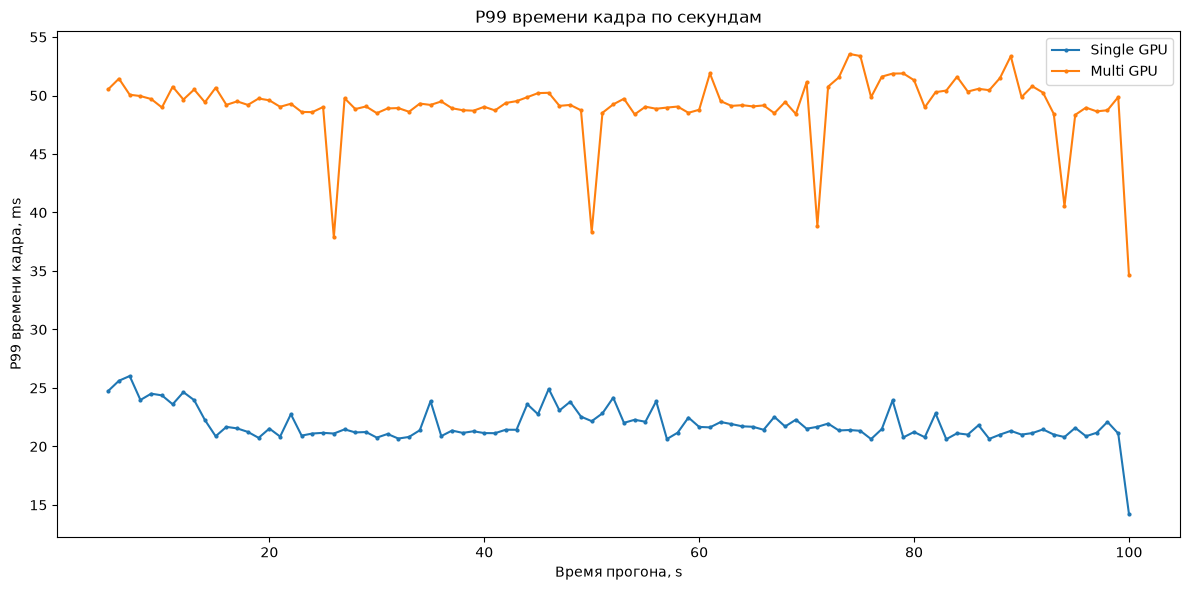

,Режим,секунд,средняя_медиана_ms,std_медианы_ms,min_медианы_ms,max_медианы_ms,средний_P99_ms,CV секундной медианы
0,Multi GPU,96,34.7027,0.7022,31.3286,37.4736,49.1307,0.0202
1,Single GPU,96,13.7879,0.9538,13.0135,16.6575,21.8695,0.0692


In [25]:
per_second_rows = []
for label in MODE_ORDER:
    grouped = (
        steady_by_mode[label]
        .groupby("second_bin")[FRAME_TIME]
        .agg(
            frames="size",
            mean_ms="mean",
            median_ms="median",
            p95_ms=lambda x: x.quantile(0.95),
            p99_ms=lambda x: x.quantile(0.99),
            max_ms="max",
        )
        .reset_index()
    )
    grouped["Режим"] = label
    per_second_rows.append(grouped)

per_second = pd.concat(per_second_rows, ignore_index=True)

plt.figure(figsize=(12, 6))
for label in MODE_ORDER:
    subset = per_second[per_second["Режим"] == label]
    plt.plot(subset["second_bin"], subset["median_ms"], marker="o", markersize=2, label=label)
plt.xlabel("Время прогона, s")
plt.ylabel("Медиана времени кадра, ms")
plt.title("Медианное время кадра по секундам")
plt.legend()
save_show("04_per_second_median.png")

plt.figure(figsize=(12, 6))
for label in MODE_ORDER:
    subset = per_second[per_second["Режим"] == label]
    plt.plot(subset["second_bin"], subset["p99_ms"], marker="o", markersize=2, label=label)
plt.xlabel("Время прогона, s")
plt.ylabel("P99 времени кадра, ms")
plt.title("P99 времени кадра по секундам")
plt.legend()
save_show("05_per_second_p99.png")

stability_table = (
    per_second.groupby("Режим")
    .agg(
        секунд=("second_bin", "count"),
        средняя_медиана_ms=("median_ms", "mean"),
        std_медианы_ms=("median_ms", "std"),
        min_медианы_ms=("median_ms", "min"),
        max_медианы_ms=("median_ms", "max"),
        средний_P99_ms=("p99_ms", "mean"),
    )
    .reset_index()
)
stability_table["CV секундной медианы"] = stability_table["std_медианы_ms"] / stability_table["средняя_медиана_ms"]
display(stability_table.round(4))

per_second.to_csv(OUTPUT_DIR / "per_second_metrics.csv", index=False, encoding="utf-8-sig")
stability_table.to_csv(OUTPUT_DIR / "stability_summary.csv", index=False, encoding="utf-8-sig")

## 6. Выполнение временных бюджетов

,Режим,Целевой FPS,"Бюджет, ms","Кадров в бюджете, %",Кадров вне бюджета
0,Single GPU,60,16.667,92.69,488
1,Single GPU,90,11.111,0.00,6676
2,Single GPU,120,8.333,0.00,6676
3,Single GPU,144,6.944,0.00,6676
4,Single GPU,165,6.061,0.00,6676
5,Single GPU,240,4.167,0.00,6676
6,Single GPU,360,2.778,0.00,6676
7,Single GPU,500,2.000,0.00,6676
8,Single GPU,600,1.667,0.00,6676
9,Multi GPU,60,16.667,2.31,2664


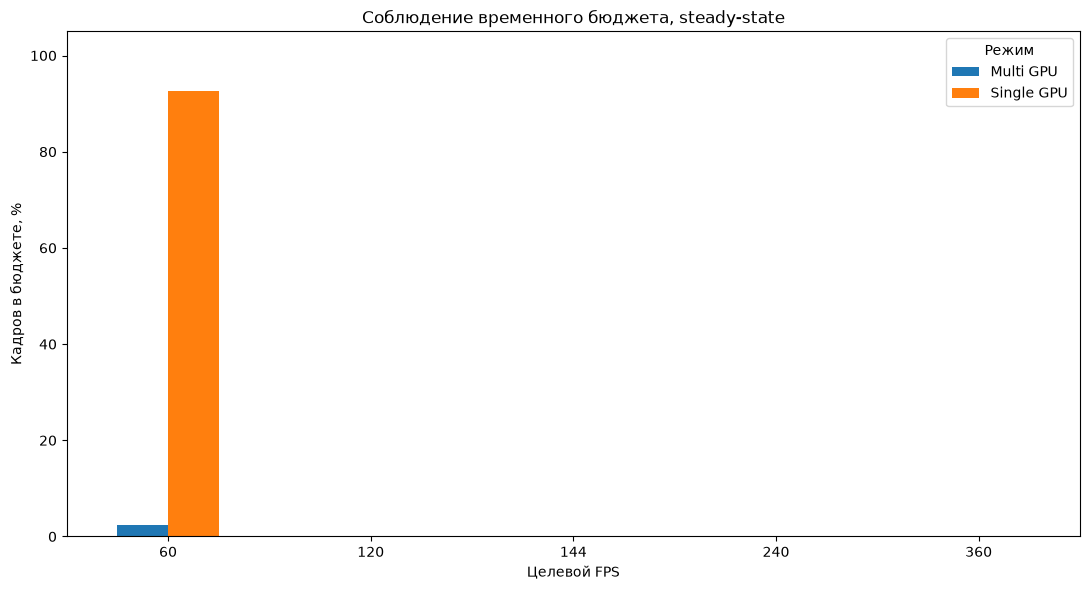

In [26]:
target_fps_values = [60, 90, 120, 144, 165, 240, 360, 500, 600]
budget_rows = []

for label in MODE_ORDER:
    values = steady_by_mode[label][FRAME_TIME]
    for target_fps in target_fps_values:
        budget_ms = 1000.0 / target_fps
        budget_rows.append({
            "Режим": label,
            "Целевой FPS": target_fps,
            "Бюджет, ms": budget_ms,
            "Кадров в бюджете, %": 100.0 * (values <= budget_ms).mean(),
            "Кадров вне бюджета": int((values > budget_ms).sum()),
        })

budget_table = pd.DataFrame(budget_rows)
display(budget_table.round(3))

budget_plot = budget_table[budget_table["Целевой FPS"].isin([60, 120, 144, 240, 360])].pivot(
    index="Целевой FPS",
    columns="Режим",
    values="Кадров в бюджете, %",
)
ax = budget_plot.plot(kind="bar", figsize=(11, 6))
ax.set_ylabel("Кадров в бюджете, %")
ax.set_xlabel("Целевой FPS")
ax.set_ylim(0, 105)
ax.set_title("Соблюдение временного бюджета, steady-state")
ax.tick_params(axis="x", rotation=0)
save_show("06_frame_budget_compliance.png")

budget_table.to_csv(OUTPUT_DIR / "frame_budget_compliance.csv", index=False, encoding="utf-8-sig")

## 7. CPU wait и ритм симуляции

,"Среднее время кадра, ms","Средний CPU wait, ms","CPU non-wait, ms","Доля CPU wait, %"
Режим,,,,
Single GPU,14.2304,0.0000,14.2304,0.0000
Multi GPU,34.8425,18.9199,15.9227,54.3011


,Simulation steps / s,"Кадров с simulation advance, %","Средний кадр с advance, ms","Средний кадр без advance, ms","P99 кадра с advance, ms","P99 кадра без advance, ms"
Режим,,,,,,
Single GPU,60.0197,84.0174,14.3616,13.5406,22.4536,16.6208
Multi GPU,59.8103,99.6333,34.9161,14.8590,54.5428,15.8868


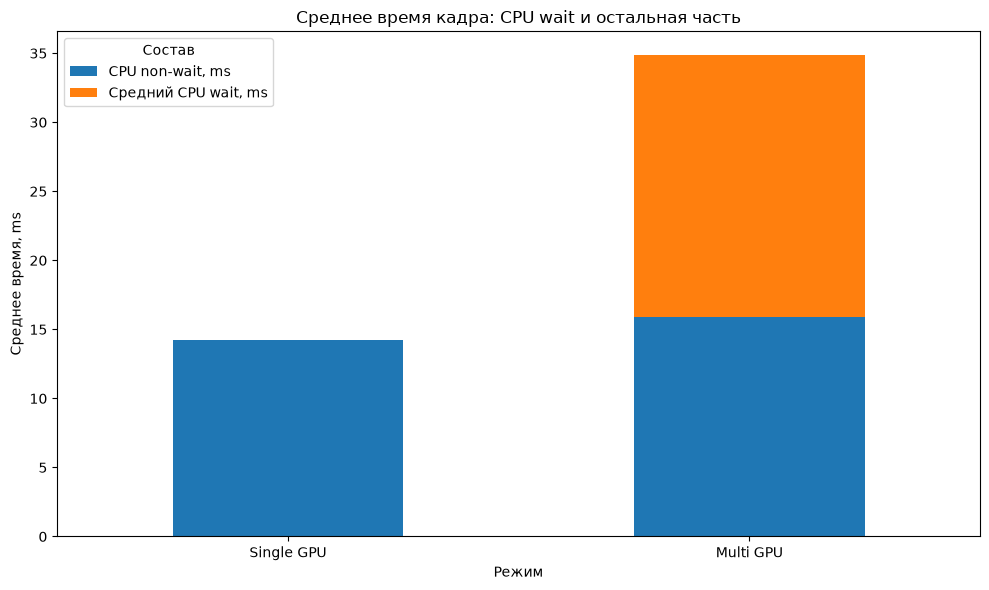

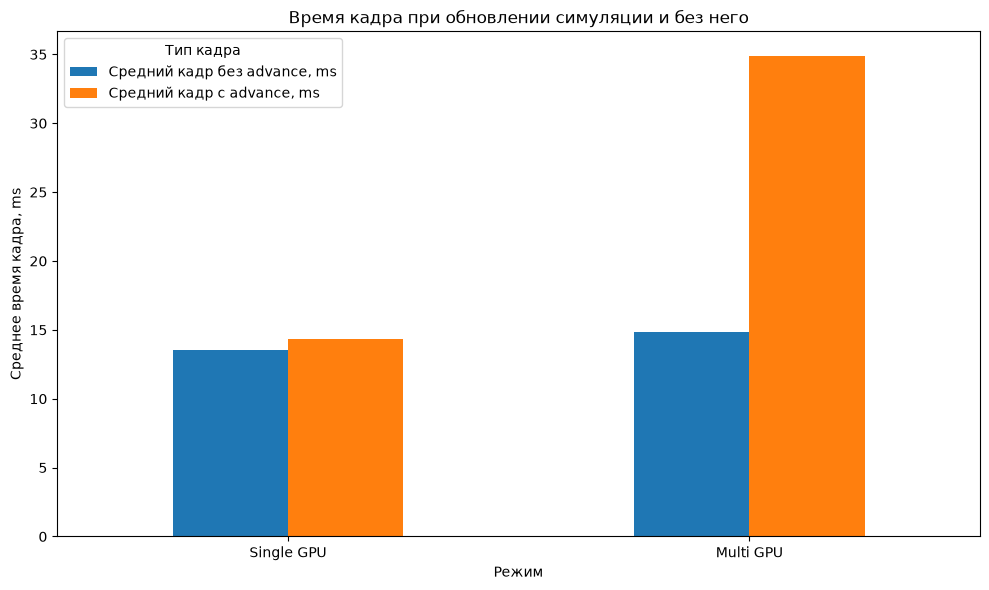

In [27]:
wait_rows = []
simulation_rows = []

for label in MODE_ORDER:
    frame = steady_by_mode[label]
    mean_frame = frame[FRAME_TIME].mean()
    mean_wait = frame["cpu_wait_ms"].mean()
    sim_advanced = frame[frame["simulation_advanced"]]
    sim_idle = frame[~frame["simulation_advanced"]]
    duration = frame["elapsed_seconds"].max() - frame["elapsed_seconds"].min()
    simulated_steps = frame["simulation_step_delta"].clip(lower=0).sum()

    wait_rows.append({
        "Режим": label,
        "Среднее время кадра, ms": mean_frame,
        "Средний CPU wait, ms": mean_wait,
        "CPU non-wait, ms": mean_frame - mean_wait,
        "Доля CPU wait, %": 100.0 * mean_wait / mean_frame,
    })

    simulation_rows.append({
        "Режим": label,
        "Simulation steps / s": simulated_steps / duration,
        "Кадров с simulation advance, %": 100.0 * frame["simulation_advanced"].mean(),
        "Средний кадр с advance, ms": sim_advanced[FRAME_TIME].mean(),
        "Средний кадр без advance, ms": sim_idle[FRAME_TIME].mean(),
        "P99 кадра с advance, ms": sim_advanced[FRAME_TIME].quantile(0.99),
        "P99 кадра без advance, ms": sim_idle[FRAME_TIME].quantile(0.99),
    })

wait_table = pd.DataFrame(wait_rows).set_index("Режим")
simulation_table = pd.DataFrame(simulation_rows).set_index("Режим")
display(wait_table.round(4))
display(simulation_table.round(4))

ax = wait_table[["CPU non-wait, ms", "Средний CPU wait, ms"]].plot(kind="bar", stacked=True, figsize=(10, 6))
ax.set_ylabel("Среднее время, ms")
ax.set_xlabel("Режим")
ax.set_title("Среднее время кадра: CPU wait и остальная часть")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Состав")
save_show("07_cpu_wait_decomposition.png")

sim_plot = simulation_table[["Средний кадр без advance, ms", "Средний кадр с advance, ms"]]
ax = sim_plot.plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("Среднее время кадра, ms")
ax.set_xlabel("Режим")
ax.set_title("Время кадра при обновлении симуляции и без него")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Тип кадра")
save_show("08_simulation_advance_cost.png")

wait_table.reset_index().to_csv(OUTPUT_DIR / "cpu_wait_summary.csv", index=False, encoding="utf-8-sig")
simulation_table.reset_index().to_csv(OUTPUT_DIR / "simulation_cadence.csv", index=False, encoding="utf-8-sig")

## 8. Периодическая задержка с циклом 30 кадров

,Режим,Кадров > 20 ms,Доминирующая фаза frame_index % 30,"Доля длинных кадров в доминирующей фазе, %","Медианный интервал между >20 ms, s","Среднее время длинного кадра, ms"
0,Single GPU,255,1,87.0588,0.4086,21.9272
1,Multi GPU,2637,1,3.4509,0.0348,35.4898


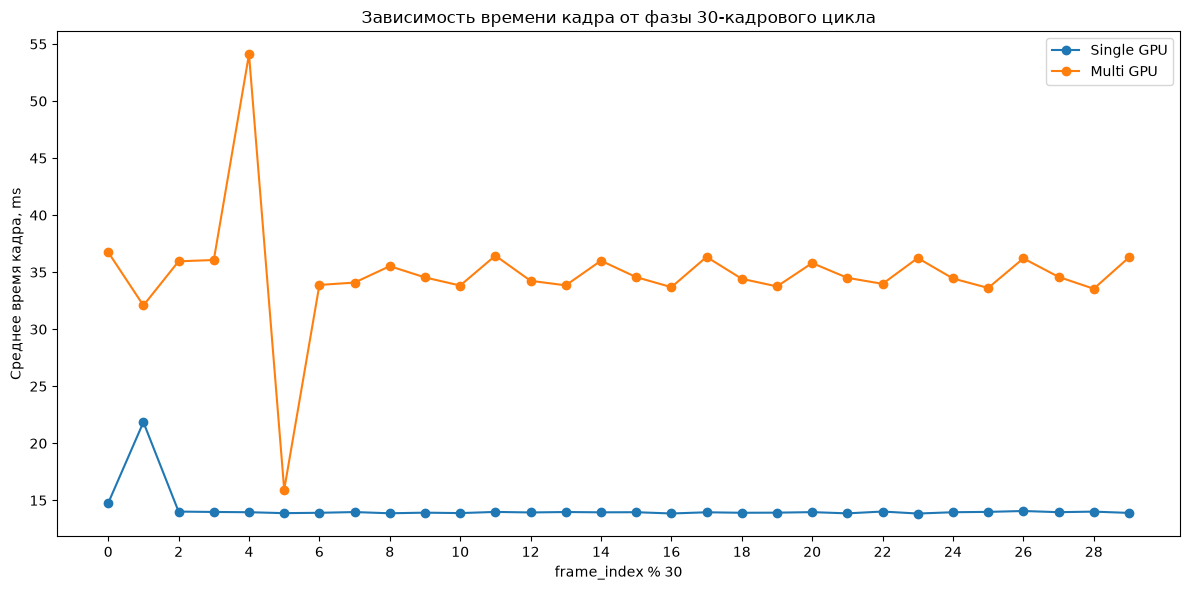

,Набор,Кадров,"Среднее, ms","Медиана, ms","P99, ms",Throughput FPS
0,"Multi GPU, все steady-state кадры",2727,34.843,34.704,54.535,28.701
1,Multi GPU без фазы 4 из 30,2636,34.178,34.624,39.100,29.259


In [28]:
phase_rows = []
periodic_rows = []

for label in MODE_ORDER:
    frame = steady_by_mode[label]
    grouped = (
        frame.groupby("frame_phase_30")
        .agg(
            frames=("frame_index", "size"),
            mean_frame_ms=(FRAME_TIME, "mean"),
            median_frame_ms=(FRAME_TIME, "median"),
            p95_frame_ms=(FRAME_TIME, lambda x: x.quantile(0.95)),
            max_frame_ms=(FRAME_TIME, "max"),
            mean_cpu_wait_ms=("cpu_wait_ms", "mean"),
            frames_over_20_ms=(FRAME_TIME, lambda x: int((x > 20.0).sum())),
        )
        .reset_index()
    )
    grouped["Режим"] = label
    phase_rows.append(grouped)

    slow = frame[frame[FRAME_TIME] > 20.0]
    phase_counts = slow["frame_phase_30"].value_counts()
    dominant_phase = int(phase_counts.index[0]) if not phase_counts.empty else np.nan
    dominant_count = int(phase_counts.iloc[0]) if not phase_counts.empty else 0
    intervals = slow["elapsed_seconds"].diff().dropna()

    periodic_rows.append({
        "Режим": label,
        "Кадров > 20 ms": len(slow),
        "Доминирующая фаза frame_index % 30": dominant_phase,
        "Доля длинных кадров в доминирующей фазе, %": 100.0 * dominant_count / len(slow) if len(slow) else np.nan,
        "Медианный интервал между >20 ms, s": intervals.median() if not intervals.empty else np.nan,
        "Среднее время длинного кадра, ms": slow[FRAME_TIME].mean() if len(slow) else np.nan,
    })

phase_table = pd.concat(phase_rows, ignore_index=True)
periodic_table = pd.DataFrame(periodic_rows)

display(periodic_table.round(4))

plt.figure(figsize=(12, 6))
for label in MODE_ORDER:
    subset = phase_table[phase_table["Режим"] == label]
    plt.plot(subset["frame_phase_30"], subset["mean_frame_ms"], marker="o", label=label)
plt.xlabel("frame_index % 30")
plt.ylabel("Среднее время кадра, ms")
plt.title("Зависимость времени кадра от фазы 30-кадрового цикла")
plt.xticks(range(0, 30, 2))
plt.legend()
save_show("09_frame_phase_30.png")

multi_steady = steady_by_mode["Multi GPU"]
multi_without_periodic_spike = multi_steady[multi_steady["frame_phase_30"] != 4]
periodic_effect_table = pd.DataFrame([
    {
        "Набор": "Multi GPU, все steady-state кадры",
        "Кадров": len(multi_steady),
        "Среднее, ms": multi_steady[FRAME_TIME].mean(),
        "Медиана, ms": multi_steady[FRAME_TIME].median(),
        "P99, ms": multi_steady[FRAME_TIME].quantile(0.99),
        "Throughput FPS": 1000.0 / multi_steady[FRAME_TIME].mean(),
    },
    {
        "Набор": "Multi GPU без фазы 4 из 30",
        "Кадров": len(multi_without_periodic_spike),
        "Среднее, ms": multi_without_periodic_spike[FRAME_TIME].mean(),
        "Медиана, ms": multi_without_periodic_spike[FRAME_TIME].median(),
        "P99, ms": multi_without_periodic_spike[FRAME_TIME].quantile(0.99),
        "Throughput FPS": 1000.0 / multi_without_periodic_spike[FRAME_TIME].mean(),
    },
])
display(periodic_effect_table.round(3))

phase_table.to_csv(OUTPUT_DIR / "frame_phase_30.csv", index=False, encoding="utf-8-sig")
periodic_table.to_csv(OUTPUT_DIR / "periodic_stall_summary.csv", index=False, encoding="utf-8-sig")
periodic_effect_table.to_csv(OUTPUT_DIR / "periodic_stall_effect.csv", index=False, encoding="utf-8-sig")

## 9. Разделение workload и стоимость межадаптерной передачи

,Устройство,Rendered voxels,"Доля workload, %"
0,Primary GPU,590705,83.132
1,Secondary GPU,119861,16.868


,Показатель,Значение,Единица
0,Color transfer,63.281,MiB/frame
1,Depth transfer,63.281,MiB/frame
2,Total cross-adapter transfer,126.562,MiB/frame
3,Требуемый поток при наблюдаемом FPS,3.547,GiB/s
4,Передача на один output pixel,64.000,bytes/pixel/frame
5,Secondary draw calls,2.000,calls/frame


,Показатель,Значение,Интерпретация
0,Фактически вынесенная доля workload,0.1687,Доля rendered voxels на secondary GPU
1,Идеальный верхний предел speedup,1.2029,"Линейная модель, бесконечно быстрый secondary, нулевой transfer/sync overhead"
2,Наблюдаемый speedup,0.4084,Single mean frame time / Multi mean frame time; значение < 1 означает замедление


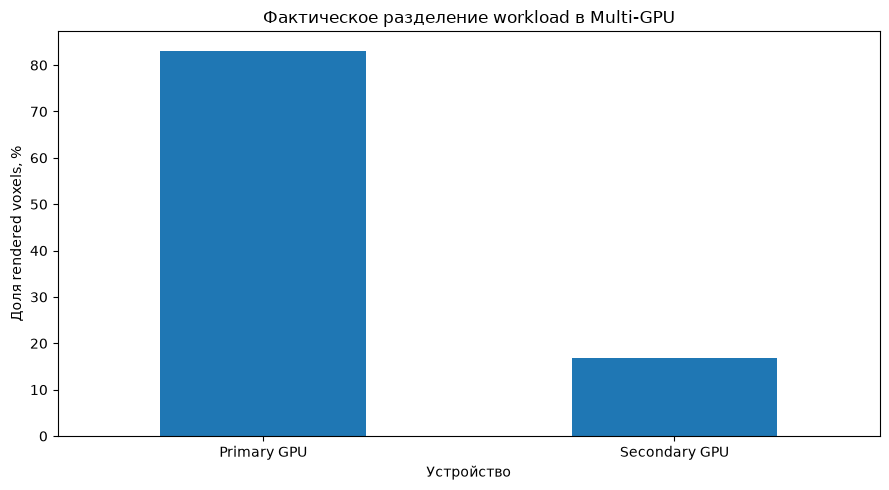

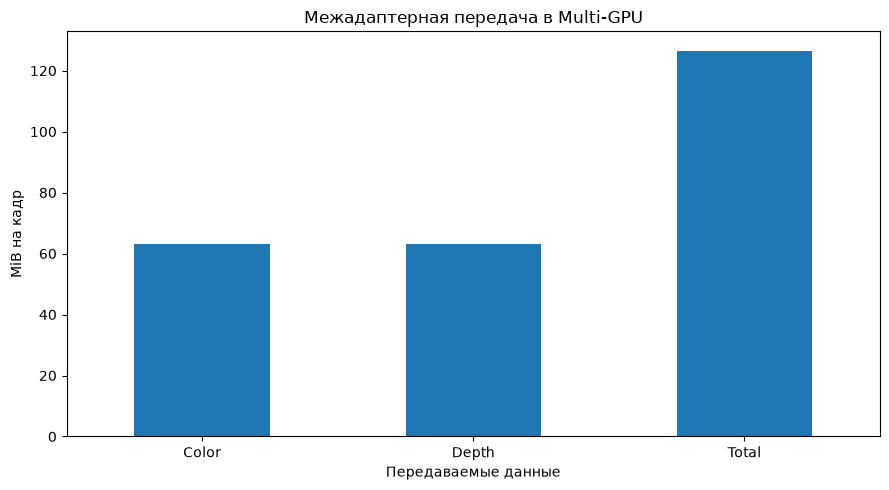

In [29]:
mgpu = steady_by_mode["Multi GPU"]
primary_voxels = float(mgpu["primary_rendered_voxels"].median())
secondary_voxels = float(mgpu["secondary_rendered_voxels"].median())
total_rendered = primary_voxels + secondary_voxels
secondary_fraction = secondary_voxels / total_rendered
primary_fraction = primary_voxels / total_rendered

throughput_fps_multi = 1000.0 / mgpu[FRAME_TIME].mean()
color_mib = mgpu["color_transfer_bytes"].median() / 2**20
depth_mib = mgpu["depth_transfer_bytes"].median() / 2**20
total_mib = mgpu["total_cross_adapter_bytes"].median() / 2**20
transfer_gib_s = mgpu["total_cross_adapter_bytes"].median() * throughput_fps_multi / 2**30
output_pixels = multi_env["render_width"] * multi_env["render_height"]
bytes_per_output_pixel = mgpu["total_cross_adapter_bytes"].median() / output_pixels

workload_table = pd.DataFrame([
    {"Устройство": "Primary GPU", "Rendered voxels": int(primary_voxels), "Доля workload, %": 100.0 * primary_fraction},
    {"Устройство": "Secondary GPU", "Rendered voxels": int(secondary_voxels), "Доля workload, %": 100.0 * secondary_fraction},
])
display(workload_table.round(3))

transfer_table = pd.DataFrame([
    {"Показатель": "Color transfer", "Значение": color_mib, "Единица": "MiB/frame"},
    {"Показатель": "Depth transfer", "Значение": depth_mib, "Единица": "MiB/frame"},
    {"Показатель": "Total cross-adapter transfer", "Значение": total_mib, "Единица": "MiB/frame"},
    {"Показатель": "Требуемый поток при наблюдаемом FPS", "Значение": transfer_gib_s, "Единица": "GiB/s"},
    {"Показатель": "Передача на один output pixel", "Значение": bytes_per_output_pixel, "Единица": "bytes/pixel/frame"},
    {"Показатель": "Secondary draw calls", "Значение": float(mgpu["secondary_draw_calls"].median()), "Единица": "calls/frame"},
])
display(transfer_table.round(3))

ideal_speedup_ceiling = 1.0 / (1.0 - secondary_fraction)
observed_speedup = single_metrics["Среднее, ms"] / multi_metrics["Среднее, ms"]

upper_bound_table = pd.DataFrame([
    {
        "Показатель": "Фактически вынесенная доля workload",
        "Значение": secondary_fraction,
        "Интерпретация": "Доля rendered voxels на secondary GPU",
    },
    {
        "Показатель": "Идеальный верхний предел speedup",
        "Значение": ideal_speedup_ceiling,
        "Интерпретация": "Линейная модель, бесконечно быстрый secondary, нулевой transfer/sync overhead",
    },
    {
        "Показатель": "Наблюдаемый speedup",
        "Значение": observed_speedup,
        "Интерпретация": "Single mean frame time / Multi mean frame time; значение < 1 означает замедление",
    },
])
display(upper_bound_table.round(4))

ax = workload_table.set_index("Устройство")[["Доля workload, %"]].plot(kind="bar", figsize=(9, 5), legend=False)
ax.set_ylabel("Доля rendered voxels, %")
ax.set_xlabel("Устройство")
ax.set_title("Фактическое разделение workload в Multi-GPU")
ax.tick_params(axis="x", rotation=0)
save_show("10_mgpu_workload_share.png")

transfer_plot = pd.DataFrame({
    "MiB/frame": [color_mib, depth_mib, total_mib],
}, index=["Color", "Depth", "Total"])
ax = transfer_plot.plot(kind="bar", figsize=(9, 5), legend=False)
ax.set_ylabel("MiB на кадр")
ax.set_xlabel("Передаваемые данные")
ax.set_title("Межадаптерная передача в Multi-GPU")
ax.tick_params(axis="x", rotation=0)
save_show("11_cross_adapter_transfer.png")

workload_table.to_csv(OUTPUT_DIR / "mgpu_workload_partition.csv", index=False, encoding="utf-8-sig")
transfer_table.to_csv(OUTPUT_DIR / "mgpu_transfer_summary.csv", index=False, encoding="utf-8-sig")
upper_bound_table.to_csv(OUTPUT_DIR / "mgpu_simple_speedup_bound.csv", index=False, encoding="utf-8-sig")

## 10. Самые медленные кадры

In [30]:
slow_frame_tables = []
for label in MODE_ORDER:
    frame = steady_by_mode[label].nlargest(15, FRAME_TIME).copy()
    selected = frame[[
        "run_label",
        "elapsed_seconds",
        "frame_index",
        "frame_phase_30",
        "simulation_frame_index",
        "simulation_step_delta",
        FRAME_TIME,
        "wall_delta_ms",
        "cpu_wait_ms",
        "primary_rendered_voxels",
        "secondary_rendered_voxels",
        "total_cross_adapter_bytes",
    ]]
    slow_frame_tables.append(selected)

slow_frames = pd.concat(slow_frame_tables, ignore_index=True)
display(slow_frames.round(4))

threshold_rows = []
for label in MODE_ORDER:
    values = steady_by_mode[label][FRAME_TIME]
    for threshold in [8.333, 10.0, 16.667, 20.0, 30.0, 40.0]:
        threshold_rows.append({
            "Режим": label,
            "Порог, ms": threshold,
            "Кадров выше порога": int((values > threshold).sum()),
            "Доля, %": 100.0 * (values > threshold).mean(),
        })

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(4))

slow_frames.to_csv(OUTPUT_DIR / "slowest_frames.csv", index=False, encoding="utf-8-sig")
threshold_table.to_csv(OUTPUT_DIR / "tail_thresholds.csv", index=False, encoding="utf-8-sig")

,run_label,elapsed_seconds,frame_index,frame_phase_30,simulation_frame_index,simulation_step_delta,present_to_present_ms,wall_delta_ms,cpu_wait_ms,primary_rendered_voxels,secondary_rendered_voxels,total_cross_adapter_bytes
0,Single GPU,35.6975,2401,1,2141,2.0,30.3405,30.9034,0.0,710566,0,0
1,Single GPU,78.3882,5370,0,4701,1.0,28.4527,26.9191,0.0,710566,0,0
2,Single GPU,6.1128,342,12,365,1.0,27.0104,26.7011,0.0,710566,0,0
3,Single GPU,7.4732,421,1,447,2.0,26.4237,26.8926,0.0,710566,0,0
4,Single GPU,46.1928,3153,3,2770,1.0,26.1643,25.8521,0.0,710566,0,0
5,Single GPU,82.0608,5641,1,4922,1.0,26.0854,22.4424,0.0,710566,0,0
6,Single GPU,10.8966,631,1,652,1.0,26.0612,25.2886,0.0,710566,0,0
7,Single GPU,7.0119,394,4,419,1.0,25.7257,23.2649,0.0,710566,0,0
8,Single GPU,13.8187,811,1,828,2.0,25.2726,26.6110,0.0,710566,0,0
9,Single GPU,52.5330,3577,7,3151,2.0,24.9214,24.9276,0.0,710566,0,0


,Режим,"Порог, ms",Кадров выше порога,"Доля, %"
0,Single GPU,8.333,6676,100.0000
1,Single GPU,10.000,6676,100.0000
2,Single GPU,16.667,487,7.2948
3,Single GPU,20.000,255,3.8197
4,Single GPU,30.000,1,0.0150
5,Single GPU,40.000,0,0.0000
6,Multi GPU,8.333,2727,100.0000
7,Multi GPU,10.000,2727,100.0000
8,Multi GPU,16.667,2664,97.6898
9,Multi GPU,20.000,2637,96.6997


## 11. Итоговые выводы

In [38]:
from IPython.display import display, Markdown
import math
import numpy as np
import pandas as pd


def safe_float(value, default=np.nan):
    try:
        value = float(value)
        return value if math.isfinite(value) else default
    except (TypeError, ValueError):
        return default


def safe_ratio(numerator, denominator):
    numerator = safe_float(numerator)
    denominator = safe_float(denominator)

    if not math.isfinite(numerator) or not math.isfinite(denominator) or denominator == 0:
        return np.nan

    return numerator / denominator


def fmt_ms(value, digits=3):
    value = safe_float(value)
    return f"{value:.{digits}f} ms" if math.isfinite(value) else "n/a"


def fmt_fps(value, digits=1):
    value = safe_float(value)
    return f"{value:.{digits}f} FPS" if math.isfinite(value) else "n/a"


def fmt_percent(value, digits=1):
    value = safe_float(value)
    return f"{value:.{digits}f}%" if math.isfinite(value) else "n/a"


def fmt_ratio(value, digits=2):
    value = safe_float(value)
    return f"{value:.{digits}f}" if math.isfinite(value) else "n/a"


def get_metric(metrics, name):
    return safe_float(metrics[name]) if name in metrics else np.nan


def build_performance_conclusion(single_metrics, multi_metrics, eps=0.03):
    single_mean = get_metric(single_metrics, "Среднее, ms")
    multi_mean = get_metric(multi_metrics, "Среднее, ms")

    single_fps = get_metric(single_metrics, "Throughput FPS")
    multi_fps = get_metric(multi_metrics, "Throughput FPS")

    mean_ratio = safe_ratio(multi_mean, single_mean)
    speedup = safe_ratio(single_mean, multi_mean)
    fps_ratio = safe_ratio(multi_fps, single_fps)
    fps_retained = 100.0 * fps_ratio if math.isfinite(fps_ratio) else np.nan

    if not math.isfinite(mean_ratio):
        return "Недостаточно данных для сравнения среднего времени кадра SingleGpuFull и MultiGpuFull."

    if mean_ratio > 1.0 + eps:
        return (
            f"В исследованных диагностических прогонах `MultiGpuFull` не обеспечил ускорение. "
            f"На steady-state участке среднее время кадра увеличилось с **{fmt_ms(single_mean)}** "
            f"до **{fmt_ms(multi_mean)}**, то есть в **{fmt_ratio(mean_ratio)} раза**. "
            f"Throughput снизился с **{fmt_fps(single_fps)}** до **{fmt_fps(multi_fps)}**; "
            f"Multi-GPU сохранил около **{fmt_percent(fps_retained)}** пропускной способности Single-GPU."
        )

    if mean_ratio < 1.0 - eps:
        return (
            f"В исследованных диагностических прогонах `MultiGpuFull` показал ускорение относительно `SingleGpuFull`. "
            f"На steady-state участке среднее время кадра уменьшилось с **{fmt_ms(single_mean)}** "
            f"до **{fmt_ms(multi_mean)}**, что соответствует speedup **{fmt_ratio(speedup)}×**. "
            f"Throughput изменился с **{fmt_fps(single_fps)}** до **{fmt_fps(multi_fps)}**."
        )

    return (
        f"В исследованных диагностических прогонах `MultiGpuFull` показал производительность, близкую к `SingleGpuFull`. "
        f"Среднее время кадра изменилось с **{fmt_ms(single_mean)}** до **{fmt_ms(multi_mean)}**, "
        f"а throughput — с **{fmt_fps(single_fps)}** до **{fmt_fps(multi_fps)}**. "
        f"Разница находится в пределах около **{fmt_percent(100.0 * abs(mean_ratio - 1.0))}**."
    )


def build_tail_conclusion(single_metrics, multi_metrics, eps=0.03):
    single_median = get_metric(single_metrics, "Медиана, ms")
    multi_median = get_metric(multi_metrics, "Медиана, ms")
    single_p99 = get_metric(single_metrics, "P99, ms")
    multi_p99 = get_metric(multi_metrics, "P99, ms")

    median_ratio = safe_ratio(multi_median, single_median)
    p99_ratio = safe_ratio(multi_p99, single_p99)

    parts = []

    if math.isfinite(median_ratio):
        if median_ratio > 1.0 + eps:
            parts.append(
                f"Медианное время кадра выросло с **{fmt_ms(single_median)}** до **{fmt_ms(multi_median)}**, "
                f"то есть в **{fmt_ratio(median_ratio)} раза**."
            )
        elif median_ratio < 1.0 - eps:
            parts.append(
                f"Медианное время кадра снизилось с **{fmt_ms(single_median)}** до **{fmt_ms(multi_median)}**, "
                f"что соответствует улучшению в **{fmt_ratio(1.0 / median_ratio)} раза**."
            )
        else:
            parts.append(
                f"Медианное время кадра осталось близким: **{fmt_ms(single_median)}** против **{fmt_ms(multi_median)}**."
            )

    if math.isfinite(p99_ratio):
        if p99_ratio > 1.0 + eps:
            parts.append(
                f"Хвост распределения также ухудшился: P99 вырос с **{fmt_ms(single_p99)}** "
                f"до **{fmt_ms(multi_p99)}**, то есть в **{fmt_ratio(p99_ratio)} раза**."
            )
        elif p99_ratio < 1.0 - eps:
            parts.append(
                f"Хвост распределения улучшился: P99 снизился с **{fmt_ms(single_p99)}** "
                f"до **{fmt_ms(multi_p99)}**."
            )
        else:
            parts.append(
                f"P99 остался близким: **{fmt_ms(single_p99)}** против **{fmt_ms(multi_p99)}**."
            )

    if not parts:
        return "Недостаточно данных для анализа медианы и хвостовых метрик."

    return " ".join(parts)


def build_cpu_wait_conclusion(wait_table, eps_percent=5.0):
    if wait_table is None or "Multi GPU" not in wait_table.index:
        return "Недостаточно данных для анализа CPU wait."

    multi_mean_frame = safe_float(wait_table.loc["Multi GPU", "Среднее время кадра, ms"])
    multi_wait = safe_float(wait_table.loc["Multi GPU", "Средний CPU wait, ms"])
    wait_share = safe_float(wait_table.loc["Multi GPU", "Доля CPU wait, %"])

    if not math.isfinite(wait_share):
        return "Недостаточно данных для оценки доли CPU wait в Multi-GPU режиме."

    if wait_share >= 30.0:
        return (
            f"`MultiGpuFull` имеет значительный CPU wait: **{fmt_ms(multi_wait)}** "
            f"из среднего времени кадра **{fmt_ms(multi_mean_frame)}**, то есть около **{fmt_percent(wait_share)}**. "
            f"Это указывает на существенные накладные расходы ожидания, синхронизации или backpressure в multi-GPU pipeline."
        )

    if wait_share >= eps_percent:
        return (
            f"В `MultiGpuFull` заметен CPU wait: **{fmt_ms(multi_wait)}**, "
            f"или около **{fmt_percent(wait_share)}** среднего времени кадра. "
            f"Эта величина может влиять на результат, но не является единственным доминирующим фактором."
        )

    return (
        f"CPU wait в `MultiGpuFull` невелик: около **{fmt_percent(wait_share)}** среднего времени кадра. "
        f"По этим данным CPU-side ожидание не выглядит основной причиной изменения производительности."
    )


def build_periodic_conclusion(periodic_table, dominance_threshold_percent=60.0):
    if periodic_table is None or "Режим" not in periodic_table.columns:
        return "Данных для анализа периодических задержек нет."

    rows = periodic_table[periodic_table["Режим"] == "Multi GPU"]
    if rows.empty:
        return "Для Multi-GPU режима нет данных по длинным кадрам и фазам кадра."

    row = rows.iloc[0]

    slow_count = int(safe_float(row.get("Кадров > 20 ms", 0), 0))
    dominant_phase = row.get("Доминирующая фаза frame_index % 30", np.nan)
    dominant_share = safe_float(row.get("Доля длинных кадров в доминирующей фазе, %", np.nan))
    median_interval = safe_float(row.get("Медианный интервал между >20 ms, s", np.nan))
    mean_slow_frame = safe_float(row.get("Среднее время длинного кадра, ms", np.nan))

    if slow_count <= 0:
        return (
            "В `MultiGpuFull` не обнаружено кадров дольше 20 ms на steady-state участке. "
            "По этим данным периодические задержки не выявлены."
        )

    if math.isfinite(dominant_share) and dominant_share >= dominance_threshold_percent:
        return (
            f"В `MultiGpuFull` обнаружена концентрация длинных кадров: **{slow_count}** кадров дольше 20 ms, "
            f"из них **{fmt_percent(dominant_share)}** попали в фазу `frame_index % 30 == {dominant_phase}`. "
            f"Среднее время длинного кадра составило **{fmt_ms(mean_slow_frame)}**. "
            f"Это похоже на периодический stall, но точную причину нужно подтверждать GPU timestamps и fence telemetry."
        )

    if math.isfinite(dominant_share):
        return (
            f"В `MultiGpuFull` обнаружено **{slow_count}** кадров дольше 20 ms, "
            f"но они не сконцентрированы в одной фазе 30-кадрового цикла: максимальная доля одной фазы составляет только "
            f"**{fmt_percent(dominant_share)}**. "
            f"Поэтому по этим данным нельзя утверждать наличие детерминированной задержки с периодом 30 кадров."
        )

    return (
        f"В `MultiGpuFull` обнаружено **{slow_count}** кадров дольше 20 ms. "
        f"Данных о доминирующей фазе недостаточно, поэтому вывод о периодичности не формулируется."
    )


def build_workload_transfer_conclusion(secondary_fraction, total_mib, single_metrics, multi_metrics):
    secondary_fraction = safe_float(secondary_fraction)
    total_mib = safe_float(total_mib)

    single_mean = get_metric(single_metrics, "Среднее, ms")
    multi_mean = get_metric(multi_metrics, "Среднее, ms")
    observed_speedup = safe_ratio(single_mean, multi_mean)

    parts = []

    if math.isfinite(secondary_fraction):
        secondary_percent = 100.0 * secondary_fraction
        parts.append(f"Secondary GPU обработал около **{fmt_percent(secondary_percent)}** rendered voxels.")

        if 0.0 <= secondary_fraction < 1.0:
            ideal_speedup_ceiling = 1.0 / (1.0 - secondary_fraction)

            parts.append(
                f"Даже в упрощённой идеальной модели без transfer/sync overhead верхняя оценка speedup составляет "
                f"примерно **{fmt_ratio(ideal_speedup_ceiling)}×**."
            )

    if math.isfinite(total_mib):
        parts.append(f"При этом межадаптерная передача составила около **{total_mib:.2f} MiB/frame**.")

    if math.isfinite(observed_speedup):
        if observed_speedup < 1.0:
            parts.append(
                f"Наблюдаемый speedup равен **{fmt_ratio(observed_speedup)}×**, то есть фактически получено замедление."
            )
        else:
            parts.append(
                f"Наблюдаемый speedup равен **{fmt_ratio(observed_speedup)}×**."
            )

    if not parts:
        return "Недостаточно данных для анализа распределения workload и межадаптерной передачи."

    return " ".join(parts)


def build_scientific_limitation(provenance_table=None):
    limitations = []

    if provenance_table is not None and isinstance(provenance_table, pd.DataFrame):
        if "Git state" in provenance_table.columns:
            dirty_modes = provenance_table[provenance_table["Git state"].astype(str).str.lower() != "clean"]
            if not dirty_modes.empty:
                modes = ", ".join(dirty_modes["Режим"].astype(str).tolist()) if "Режим" in dirty_modes.columns else "части запусков"
                limitations.append(f"git state не является clean для: {modes}.")

        if "Git commit" in provenance_table.columns:
            unique_commits = provenance_table["Git commit"].dropna().astype(str).unique()
            if len(unique_commits) > 1:
                limitations.append("сравниваемые режимы были получены из разных commit.")

    if limitations:
        return (
            "Эти результаты являются **описательными и диагностическими**, а не финальной проверкой гипотезы о производительности: "
            + " ".join(limitations)
            + " Для строгого причинного вывода нужны несколько независимых повторов из clean-сборки, одинаковая версия кода и рандомизированный порядок запусков."
        )

    return (
        "Эти результаты являются **описательными и диагностическими**, а не финальной проверкой гипотезы о производительности. "
    )


provenance = globals().get("provenance_table", None)

conclusion_items = [
    build_performance_conclusion(single_metrics, multi_metrics),
    build_tail_conclusion(single_metrics, multi_metrics),
    build_cpu_wait_conclusion(wait_table),
    build_periodic_conclusion(periodic_table),
    build_workload_transfer_conclusion(secondary_fraction, total_mib, single_metrics, multi_metrics),
]

formal_conclusion = "### Наблюдаемые результаты\n\n"

for index, item in enumerate(conclusion_items, start=1):
    formal_conclusion += f"{index}. {item}\n\n"

formal_conclusion += "### Ограничение научного вывода\n\n"
formal_conclusion += build_scientific_limitation(provenance)

display(Markdown(formal_conclusion))

### Наблюдаемые результаты

1. В исследованных диагностических прогонах `MultiGpuFull` не обеспечил ускорение. На steady-state участке среднее время кадра увеличилось с **14.230 ms** до **34.843 ms**, то есть в **2.45 раза**. Throughput снизился с **70.3 FPS** до **28.7 FPS**; Multi-GPU сохранил около **40.8%** пропускной способности Single-GPU.

2. Медианное время кадра выросло с **13.615 ms** до **34.704 ms**, то есть в **2.55 раза**. Хвост распределения также ухудшился: P99 вырос с **22.244 ms** до **54.535 ms**, то есть в **2.45 раза**.

3. `MultiGpuFull` имеет значительный CPU wait: **18.920 ms** из среднего времени кадра **34.843 ms**, то есть около **54.3%**. Это указывает на существенные накладные расходы ожидания, синхронизации или backpressure в multi-GPU pipeline.

4. В `MultiGpuFull` обнаружено **2637** кадров дольше 20 ms, но они не сконцентрированы в одной фазе 30-кадрового цикла: максимальная доля одной фазы составляет только **3.5%**. Поэтому по этим данным нельзя утверждать наличие детерминированной задержки с периодом 30 кадров.

5. Secondary GPU обработал около **16.9%** rendered voxels. Даже в упрощённой идеальной модели без transfer/sync overhead верхняя оценка speedup составляет примерно **1.20×**. При этом межадаптерная передача составила около **126.56 MiB/frame**. Наблюдаемый speedup равен **0.41×**, то есть фактически получено замедление.

### Ограничение научного вывода

Эти результаты являются **описательными и диагностическими**, а не финальной проверкой гипотезы о производительности: git state не является clean для: Single GPU, Multi GPU. Для строгого причинного вывода нужны несколько независимых повторов из clean-сборки, одинаковая версия кода и рандомизированный порядок запусков.

## 12. ИТОГОВАЯ ТАБЛИЦА

In [34]:
publication_metrics = steady_summary[[
    "Кадров",
    "Среднее, ms",
    "Медиана, ms",
    "P95, ms",
    "P99, ms",
    "Throughput FPS",
    "FPS худшего 1%",
]].reset_index()
publication_metrics.to_csv(OUTPUT_DIR / "publication_metrics.csv", index=False, encoding="utf-8-sig")

metric_dictionary = pd.DataFrame([
    {"Поле": "elapsed_seconds", "Смысл": "Время от начала измеряемого прогона"},
    {"Поле": "frame_index", "Смысл": "Индекс отрисованного кадра"},
    {"Поле": "simulation_frame_index", "Смысл": "Накопленный индекс шага симуляции"},
    {"Поле": "present_to_present_ms", "Смысл": "Основное время кадра между Present"},
    {"Поле": "wall_delta_ms", "Смысл": "Измеренный wall-clock интервал"},
    {"Поле": "cpu_wait_ms", "Смысл": "CPU wait внутри кадра"},
    {"Поле": "primary_rendered_voxels", "Смысл": "Rendered voxels primary GPU"},
    {"Поле": "secondary_rendered_voxels", "Смысл": "Rendered voxels secondary GPU"},
    {"Поле": "total_cross_adapter_bytes", "Смысл": "Общий объём межадаптерной передачи на кадр"},
    {"Поле": "color_transfer_bytes", "Смысл": "Передача color output"},
    {"Поле": "depth_transfer_bytes", "Смысл": "Передача depth output"},
    {"Поле": "secondary_draw_calls", "Смысл": "Draw calls secondary GPU"},
])
metric_dictionary.to_csv(OUTPUT_DIR / "metric_dictionary.csv", index=False, encoding="utf-8-sig")

display(publication_metrics.round(3))

,Режим,Кадров,"Среднее, ms","Медиана, ms","P95, ms","P99, ms",Throughput FPS,FPS худшего 1%
0,Single GPU,6676,14.230,13.615,17.487,22.244,70.272,41.913
1,Multi GPU,2727,34.843,34.704,38.776,54.535,28.701,17.867
